In [2]:
import os
import numpy as np
import polars as pl
import tensorflow as tf
import sys
from pathlib import Path

repo_root = Path().resolve().parents[3]
sys.path.insert(0, str(repo_root))

from src.preprocessing.preprocessing import processor
from src.models.gru import GRUModel
from src.utils.helpers import create_sequences

In [3]:
STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

WINDOW_SIZE = 72

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "file_path": "flood-dataset-top30",
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

In [4]:
pcr = processor(config)
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.6 (244.4MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,278 | Val: 341,318 | Test: 341,219
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06869950"
	"06700000"
	"06464100"
	"06892000"
	"06450500"
	…
	"06935955"
	"06061500"
	"06803495"
	"06935755"
	"06803513"
]
(4818417, 31)
X_test shape: (338699, 72, 28)
y_test shape: (338699,)


In [6]:
_tmp = GRUModel()
asymmetric_mse = _tmp._loss()

model = GRUModel.load_model(
    "gru_model_2xloss.keras",
    custom_objects={"asymmetric_mse": asymmetric_mse}
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 72, 32)         │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,517 (111.40 KB)

 Trainable params: 9,505 (37.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,012 (74.27 KB)

In [7]:
model.evaluate(X_test, y_test)

Test loss: 0.5519  |  MAE (scaled): 0.1944


In [8]:
from src.postprocessing.postprocessing import PostProcessor

pp = PostProcessor(
    model=model,
    X_test=X_test,
    y_test=y_test,
    site_ids=test_site_ids,
    target_scaler=pcr.target_scaler,
    feature_names=DYNAMIC_FEATURES + STATIC_FEATURES,
)

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10585/10585 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step
Overall test loss: 0.5519  |  MAE (scaled): 0.1944

Site 06036650:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             2029.4 CFS       2084.6 CFS    351.9 CFS


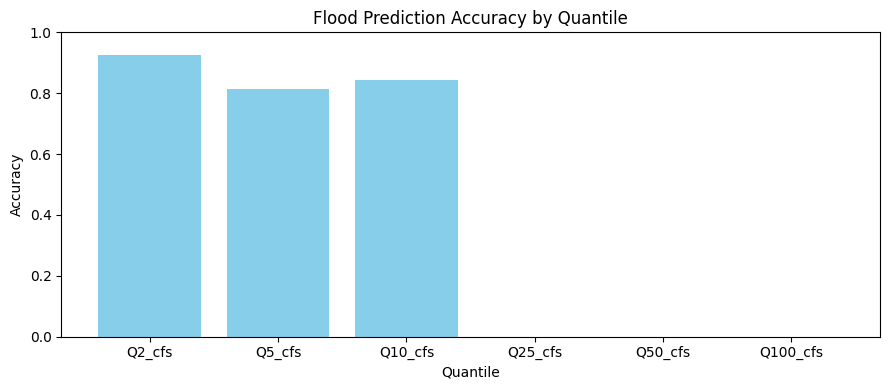


Site 06061500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               54.8 CFS         36.1 CFS     27.7 CFS


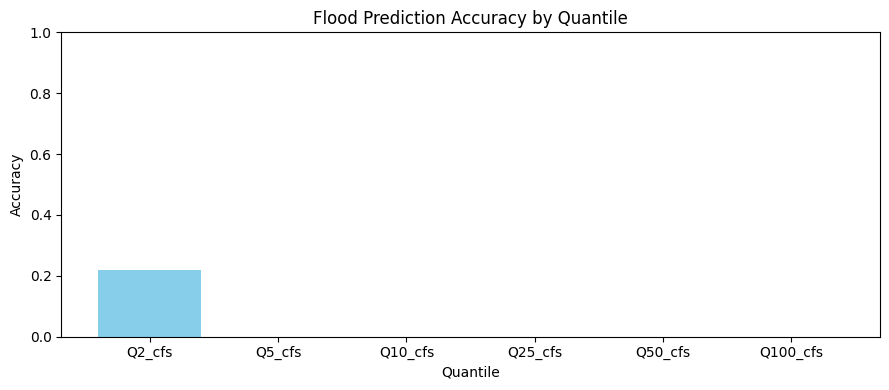


Site 06093200:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              202.0 CFS        227.2 CFS     73.3 CFS


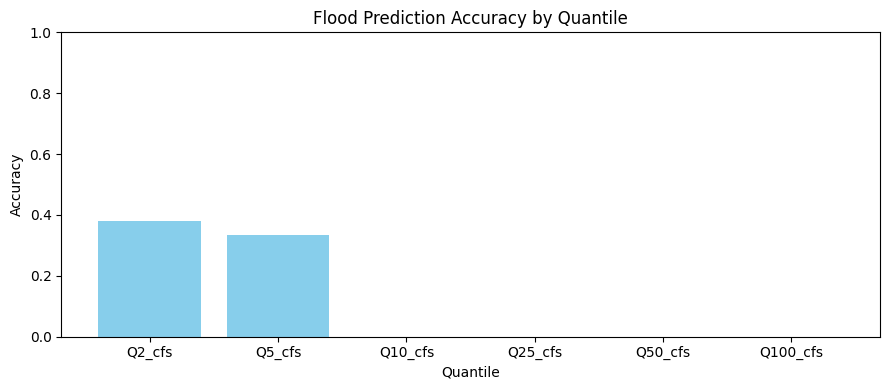


Site 06188000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1434.5 CFS       1611.7 CFS    377.0 CFS


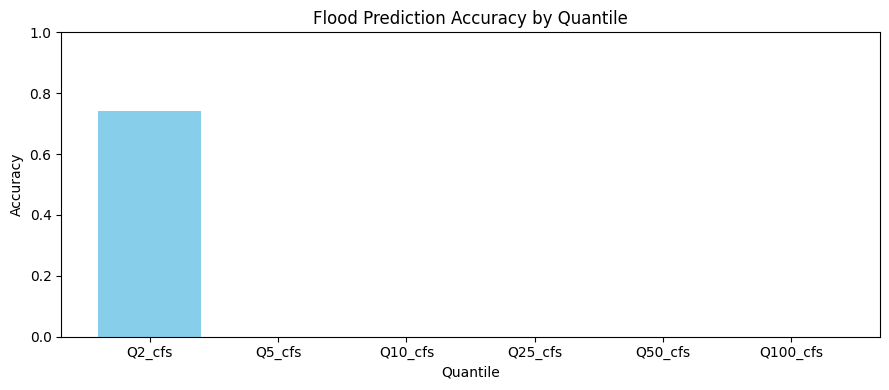


Site 06207500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1143.6 CFS       1238.1 CFS    263.0 CFS


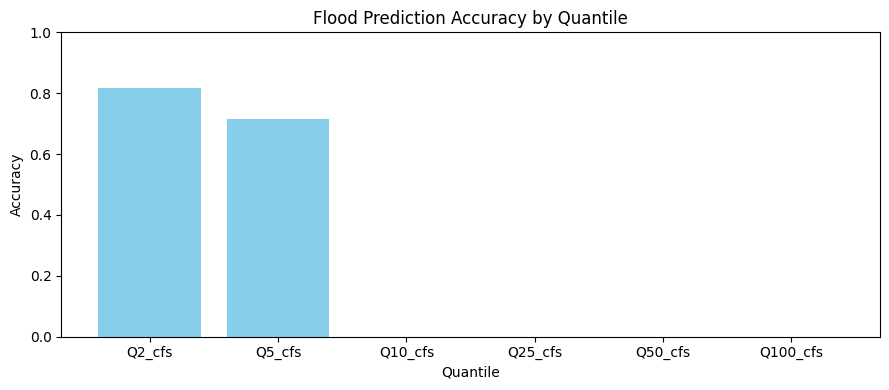


Site 06211000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              104.2 CFS        119.8 CFS     44.1 CFS


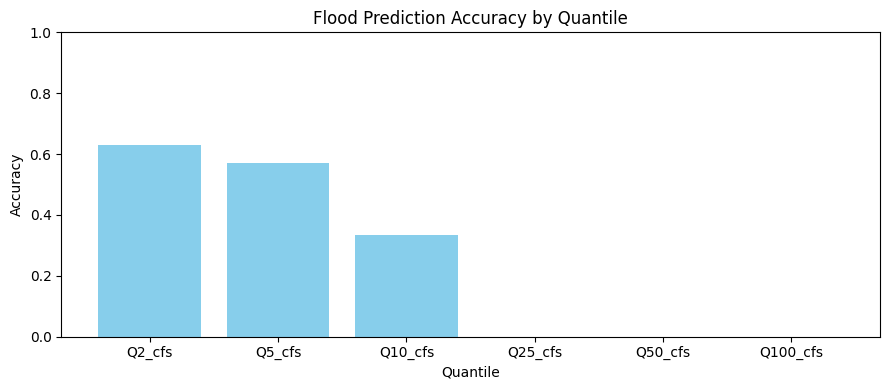


Site 06308500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              539.0 CFS        574.7 CFS    190.2 CFS


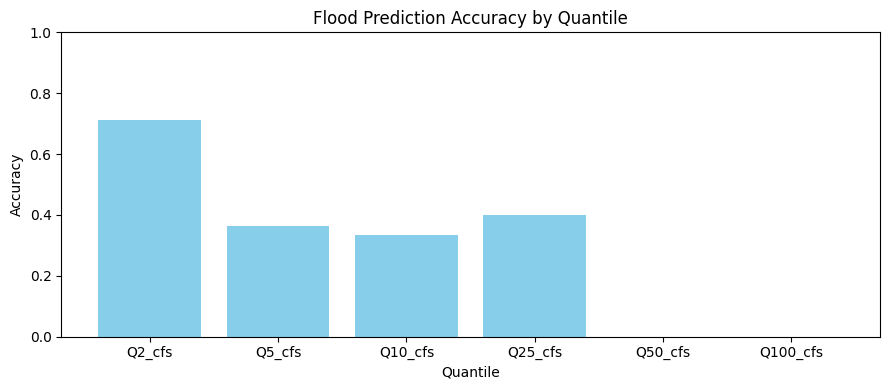


Site 06440200:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               23.4 CFS         58.4 CFS     76.1 CFS


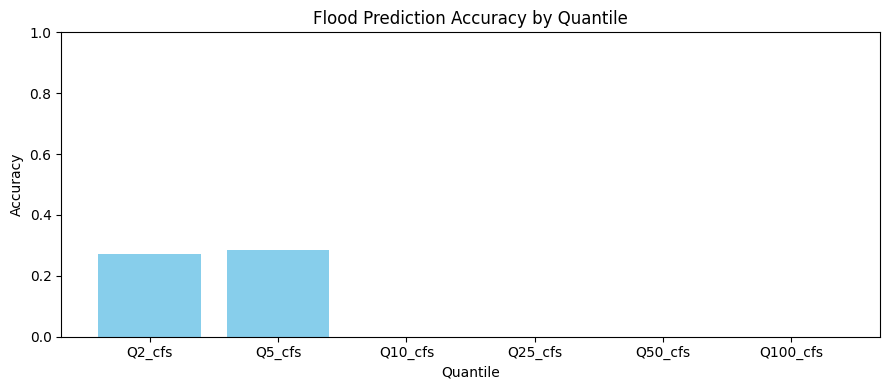


Site 06446700:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               27.1 CFS         68.0 CFS     47.4 CFS


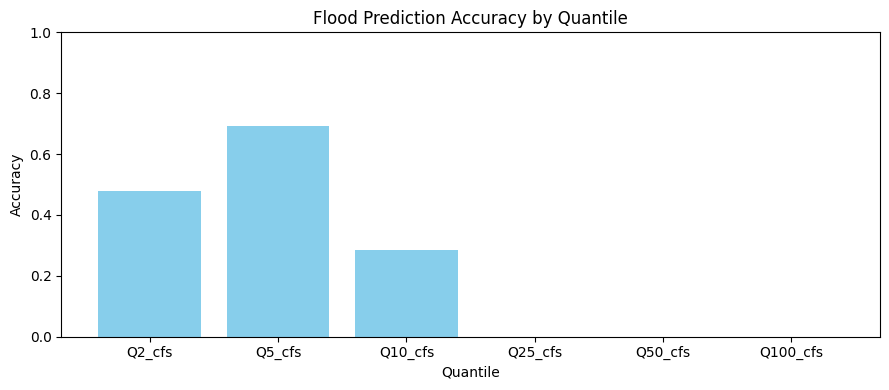


Site 06447500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               36.2 CFS         67.7 CFS     40.5 CFS


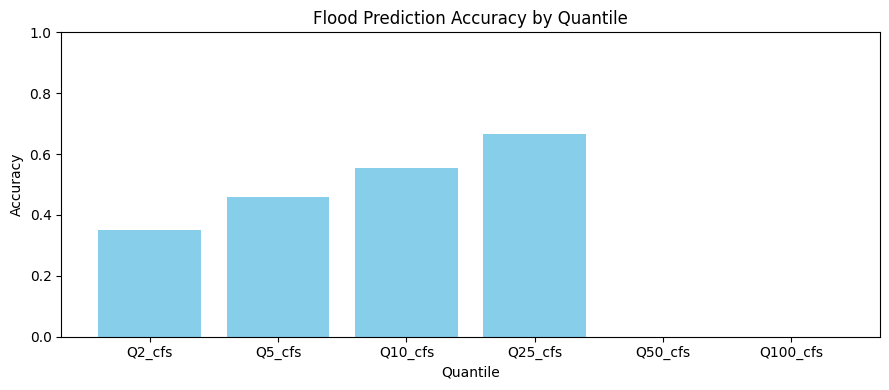


Site 06449000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               34.7 CFS         57.0 CFS     29.4 CFS


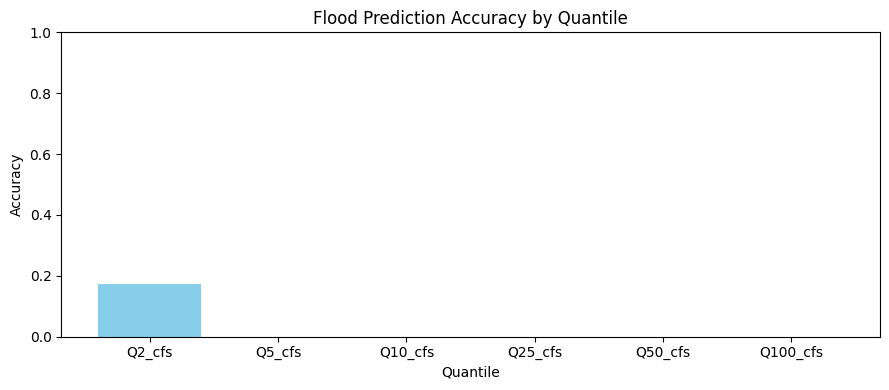


Site 06450500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              243.2 CFS        218.3 CFS     87.0 CFS


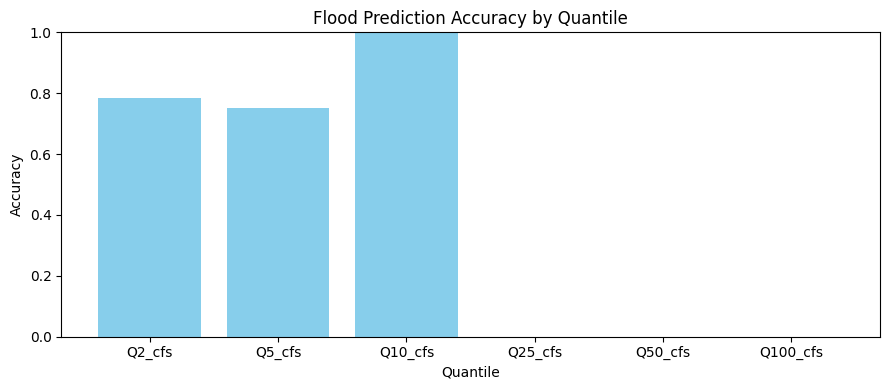


Site 06464100:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               66.6 CFS         86.1 CFS     45.3 CFS


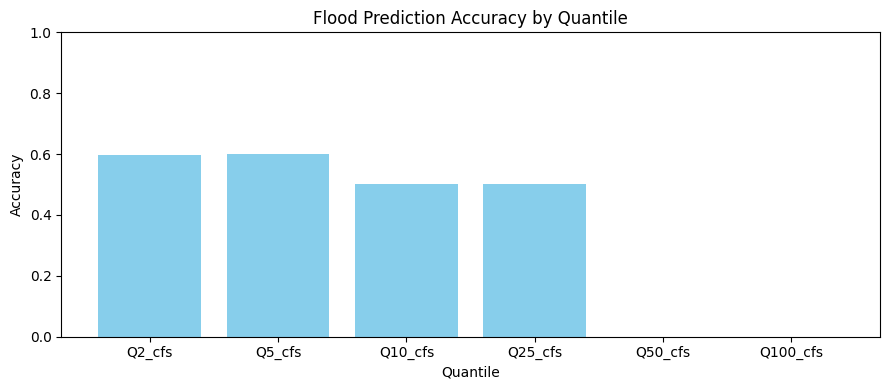


Site 06465700:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              179.7 CFS        175.3 CFS     86.4 CFS


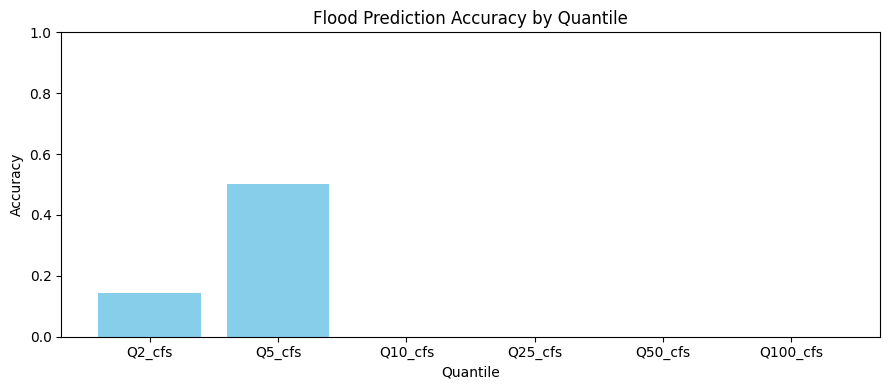


Site 06700000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              200.8 CFS        146.5 CFS     64.7 CFS


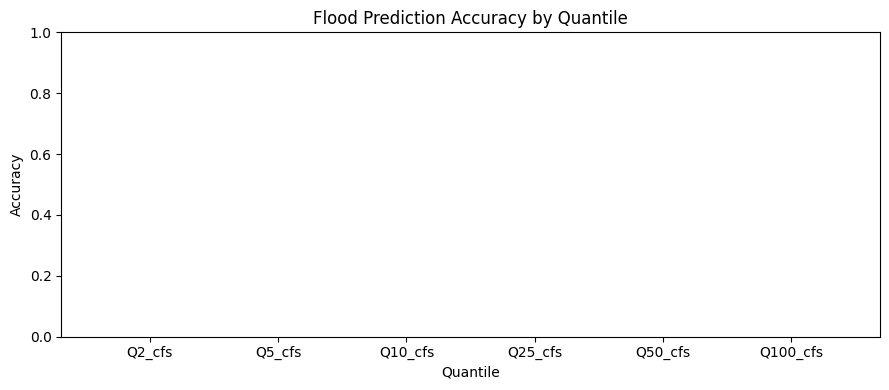


Site 06710385:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               42.7 CFS         76.5 CFS     39.3 CFS


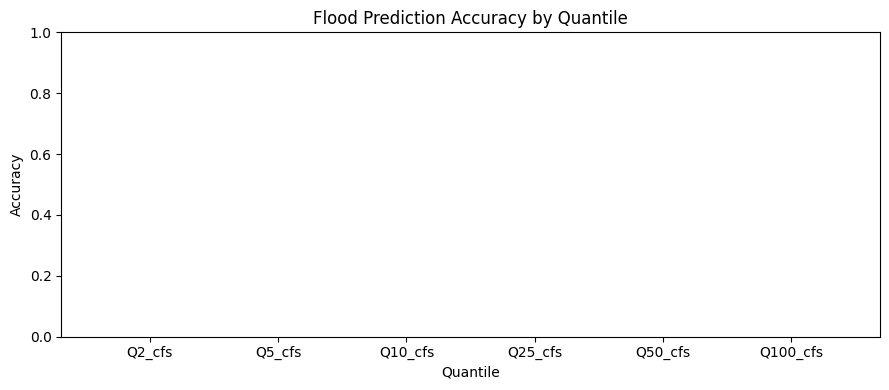


Site 06784000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              235.6 CFS        213.2 CFS     93.9 CFS


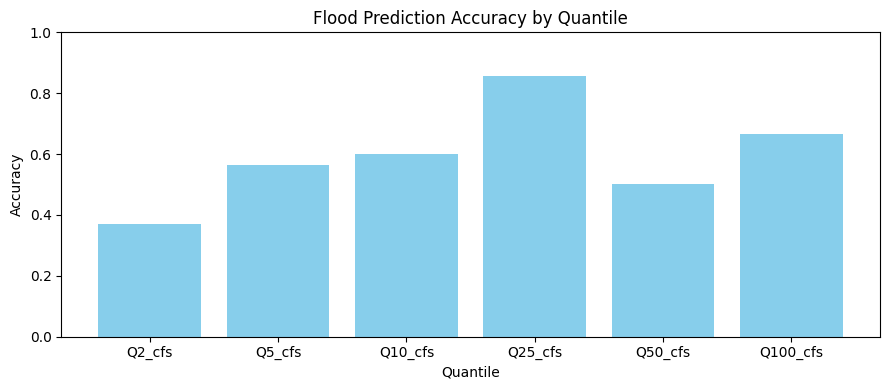


Site 06793000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1162.3 CFS       1494.3 CFS    764.9 CFS


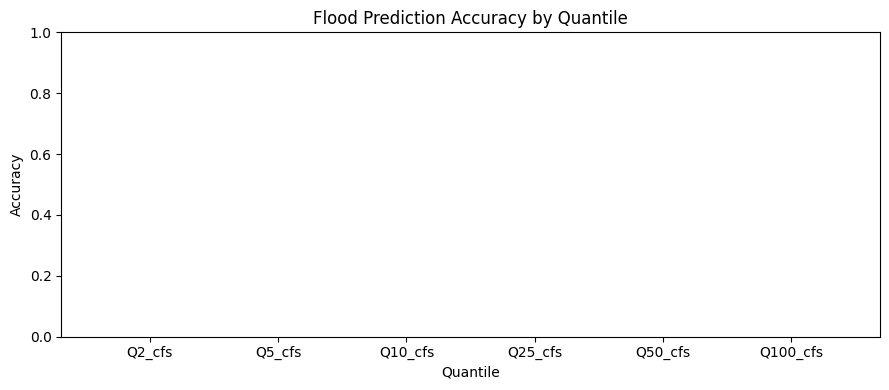


Site 06799100:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              201.2 CFS        236.9 CFS    136.7 CFS


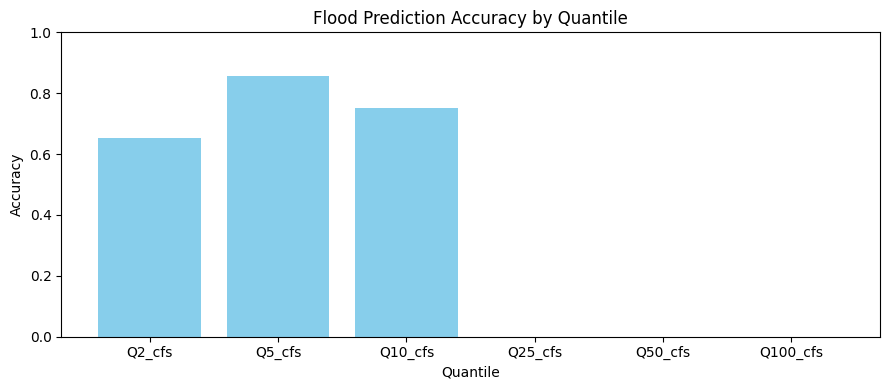


Site 06799315:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1190.1 CFS       1198.3 CFS    271.1 CFS


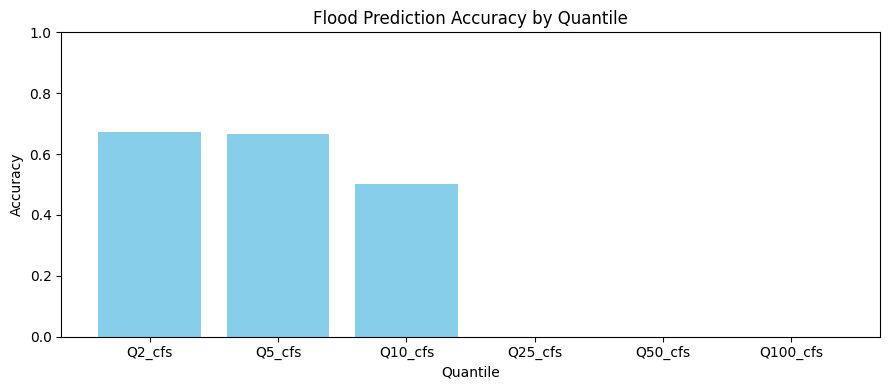


Site 06803495:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              250.8 CFS        375.1 CFS    268.6 CFS


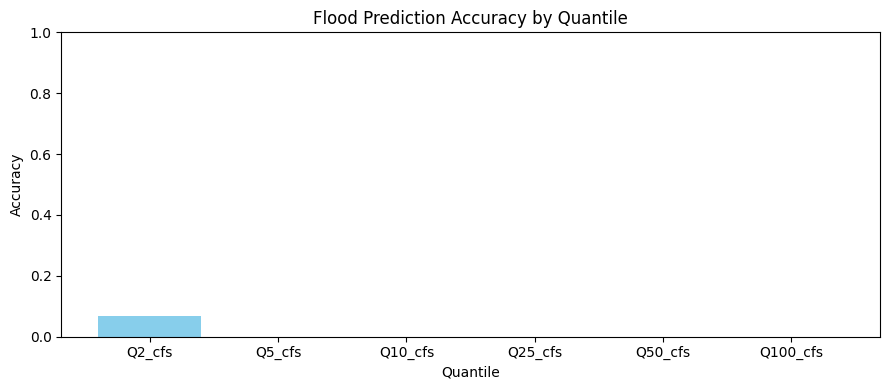


Site 06803500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              272.5 CFS        370.9 CFS    247.1 CFS


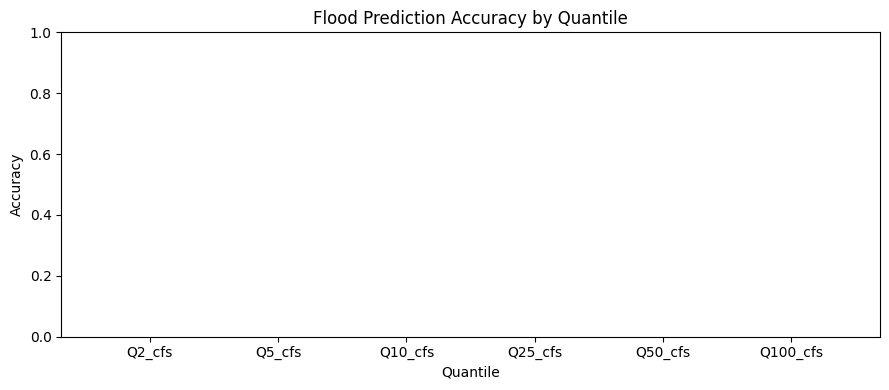


Site 06820500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1379.4 CFS       1828.5 CFS   1027.9 CFS


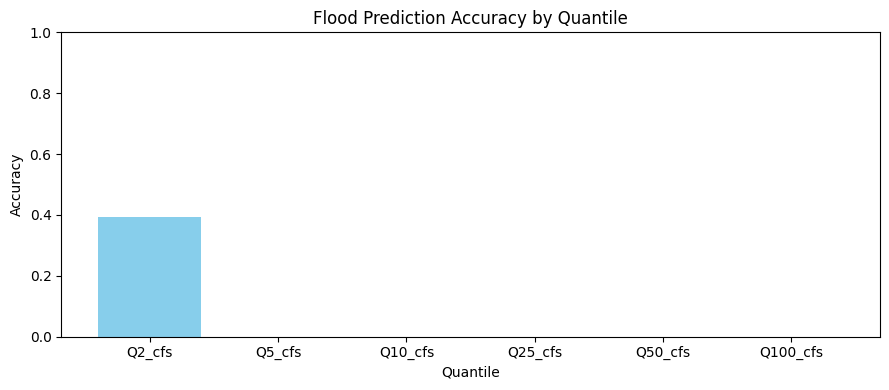


Site 06821500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test                2.4 CFS         24.9 CFS     25.1 CFS


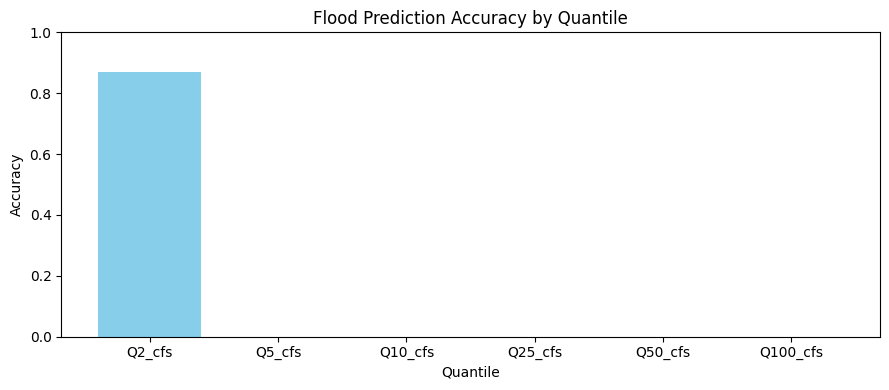


Site 06834000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               20.6 CFS         11.1 CFS     24.9 CFS


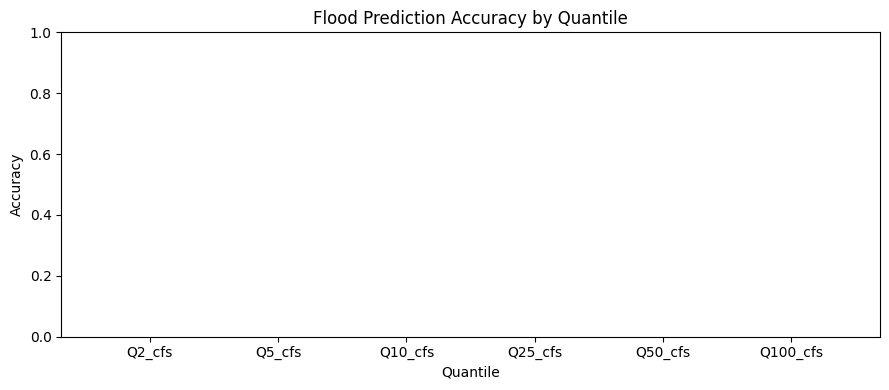


Site 06838000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               12.7 CFS         25.9 CFS     22.9 CFS


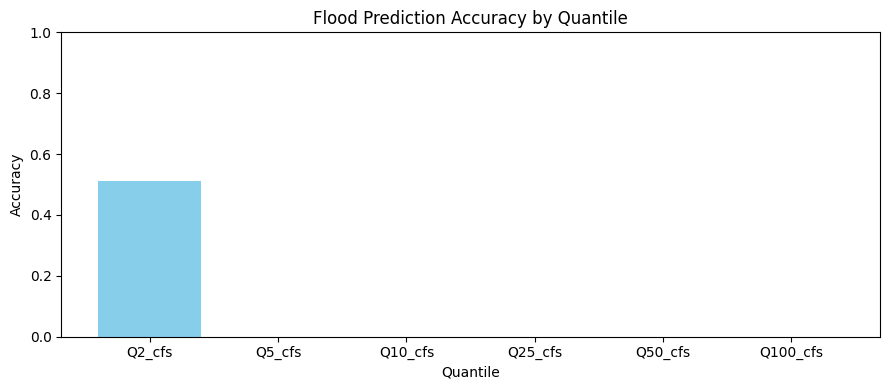


Site 06869950:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               38.8 CFS        134.6 CFS    128.2 CFS


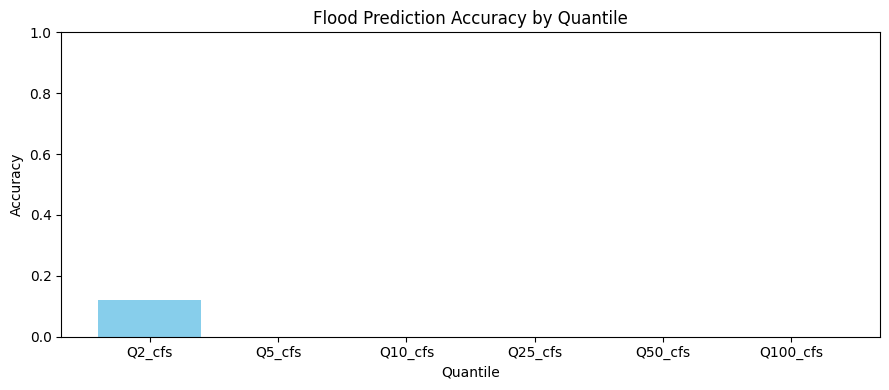


Site 06881000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              447.5 CFS        567.6 CFS    304.9 CFS


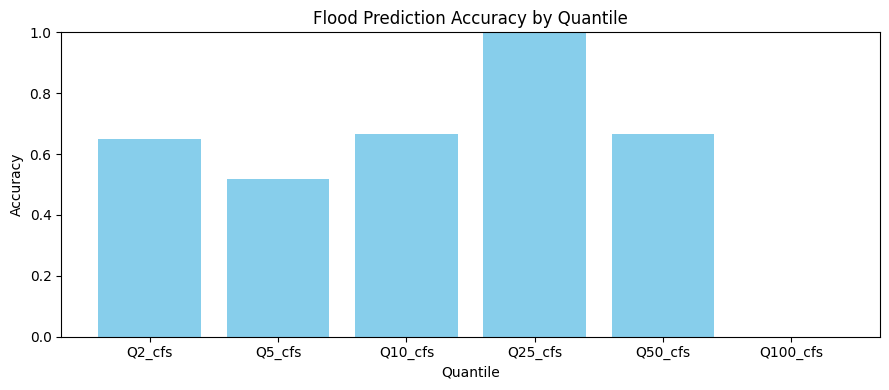


Site 06895000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              158.6 CFS        353.6 CFS    305.6 CFS


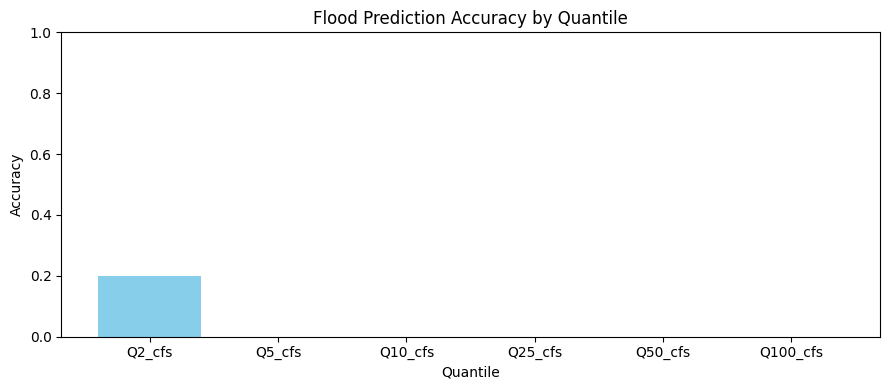


Site 06909500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               86.4 CFS        210.3 CFS    206.1 CFS


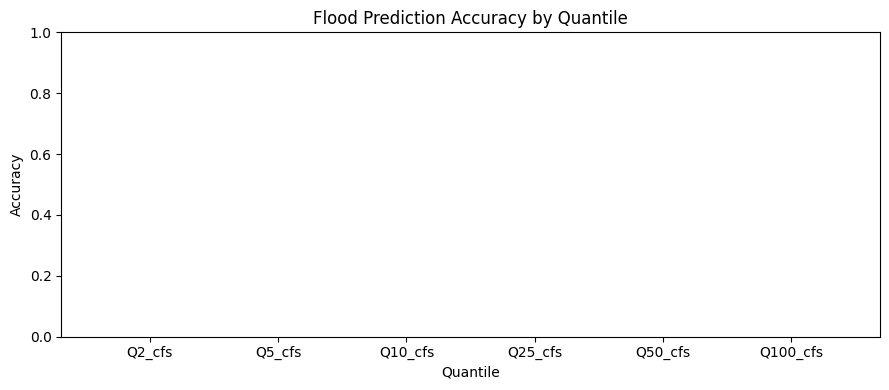


Site 06917000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              308.6 CFS        566.1 CFS    480.4 CFS


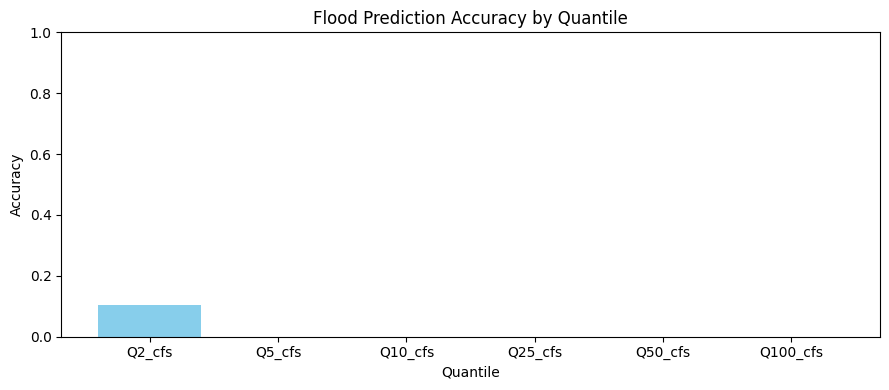


Site 06917060:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              481.3 CFS        797.1 CFS    487.1 CFS


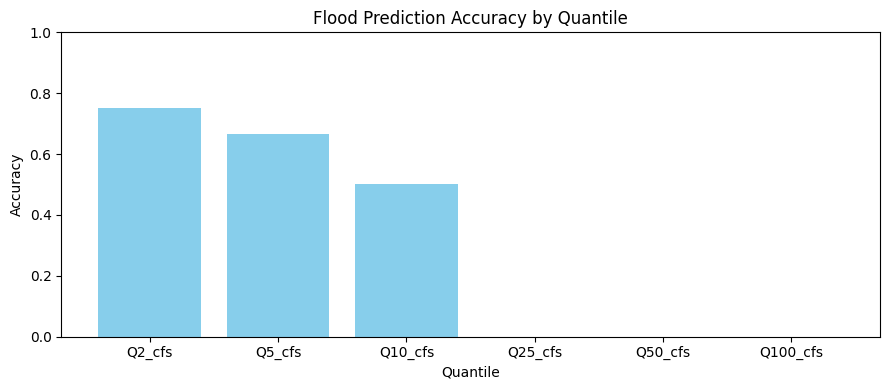


Site 06921590:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              297.0 CFS        667.1 CFS    612.8 CFS


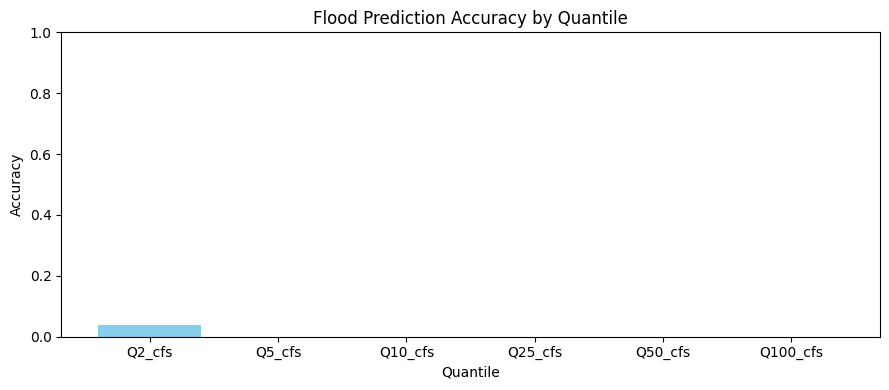


Site 06935755:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test                4.1 CFS          8.0 CFS     22.8 CFS


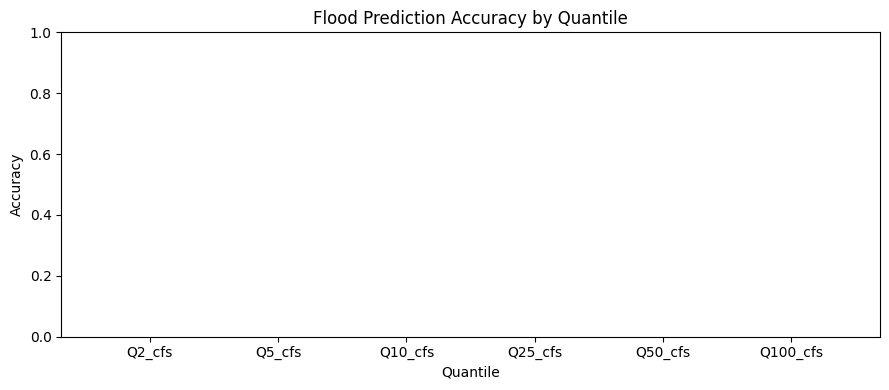


Site 06935955:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               20.5 CFS         44.4 CFS     50.7 CFS


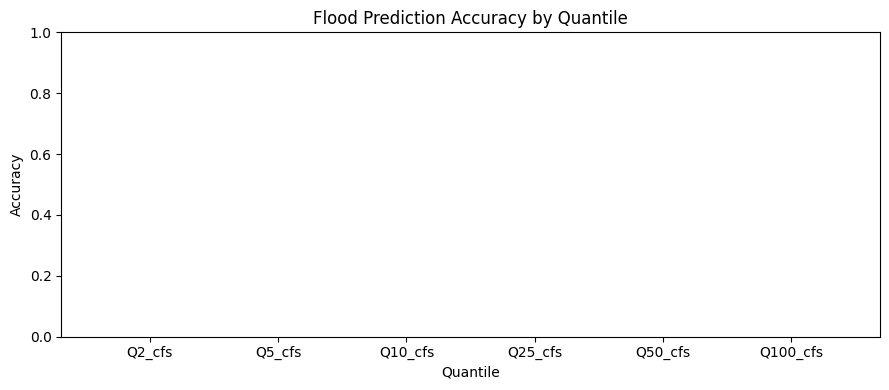

In [9]:
pp.evaluate()

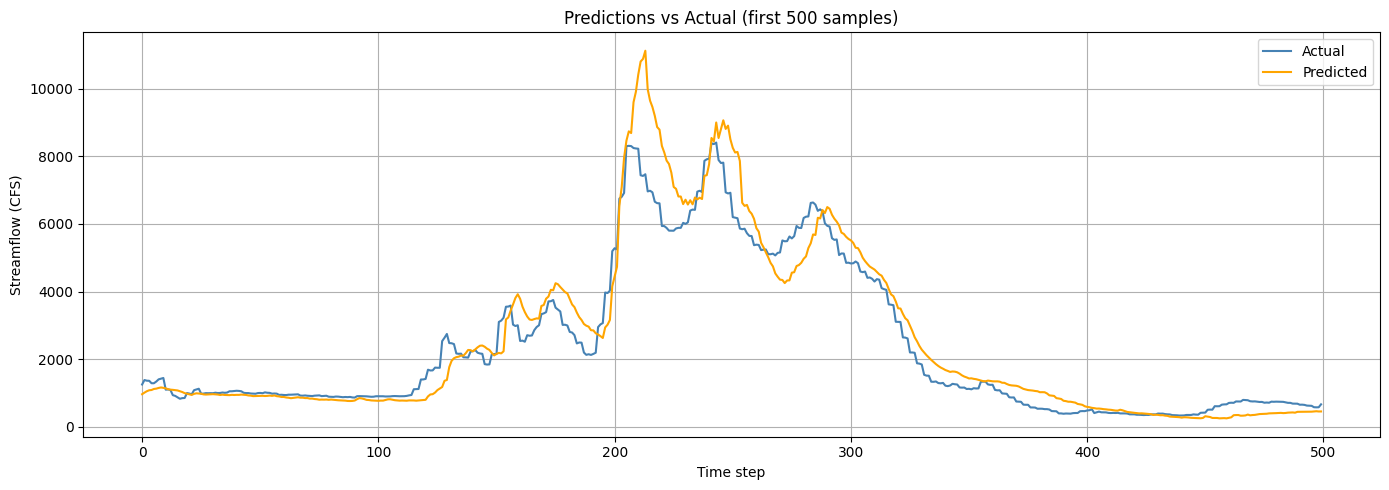

In [10]:
pp.plot_results()

In [11]:
pp.persistence_baseline()

Model                   MAE (scaled)   RMSE (scaled)        NSE
--------------------------------------------------------------
Persistence                   0.0968          0.5559     0.6955
Model                         0.1944          0.6135     0.6292


Subsampling X_test from 338699 to 300 samples for SHAP...
Computing SHAP values via KernelSHAP (nsamples=200)...


 20%|██        | 61/300 [02:03<07:56,  1.99s/it]c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=6.877e-02, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
 87%|████████▋ | 260/300 [08:48<01:20,  2.02s/it]c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=9.660e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
100%|██████████| 300/300 [10:08<00:00,  2.03s/it]


Done.


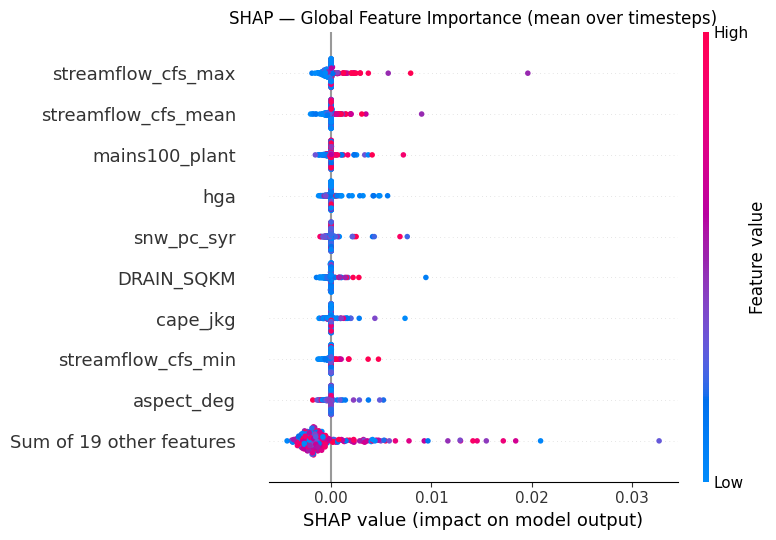

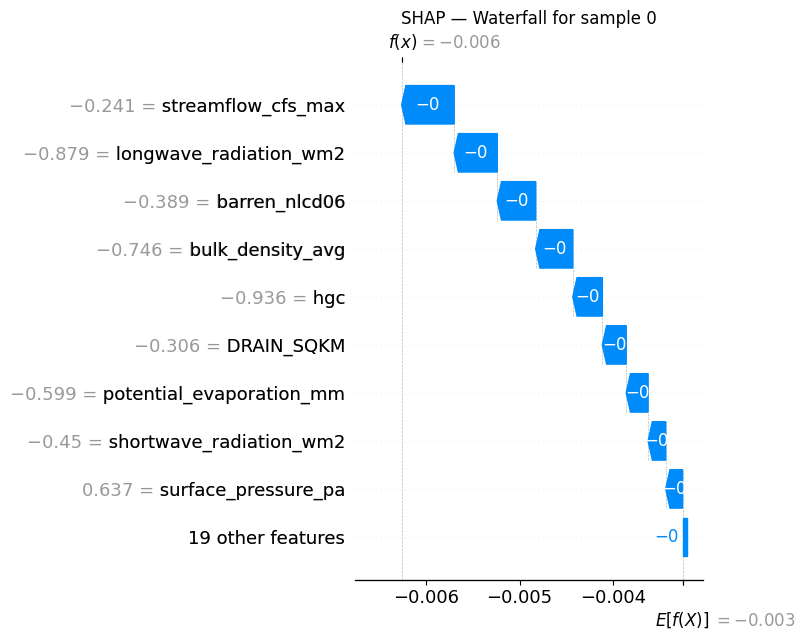

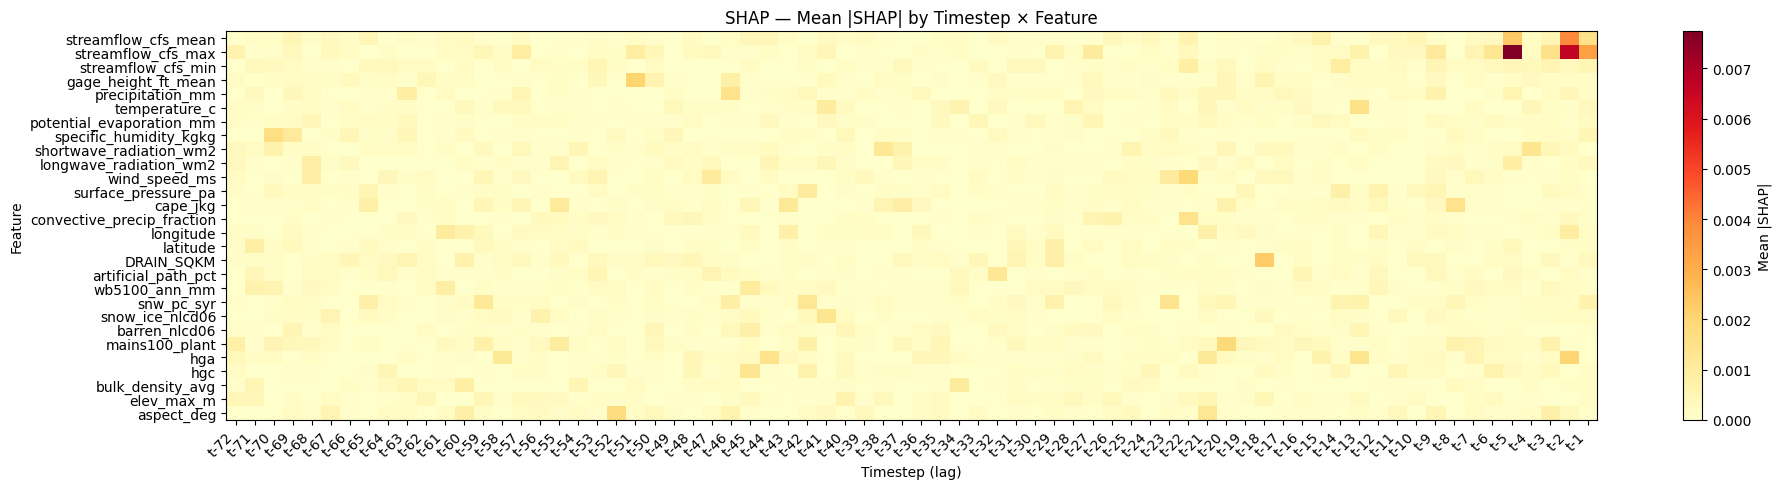

In [12]:
pp.compute_shap()